# EDA, Target Construction & PCA Analysis
**Gold Futures (GC=F) - Iteration 3 (CP1)**

This notebook covers:
1. Time series data visualization (Prices & Technical Indicators).
2. The logic of building 3-class targets (Threshold filtering).
3. Correlation Matrix to spot multi-collinearity.
4. PCA Dimensionality reduction to visualize class separability in 2D.
5. Baseline modeling comparison: Raw OHLCV vs. Feature Engineered (39 features).


In [16]:
%pip install -r ../requirements.txt


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

import sys
sys.path.append('..')
from src.preprocessing import load_raw_data, clean_data, add_features, create_target


RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 1. Time Series Visualization

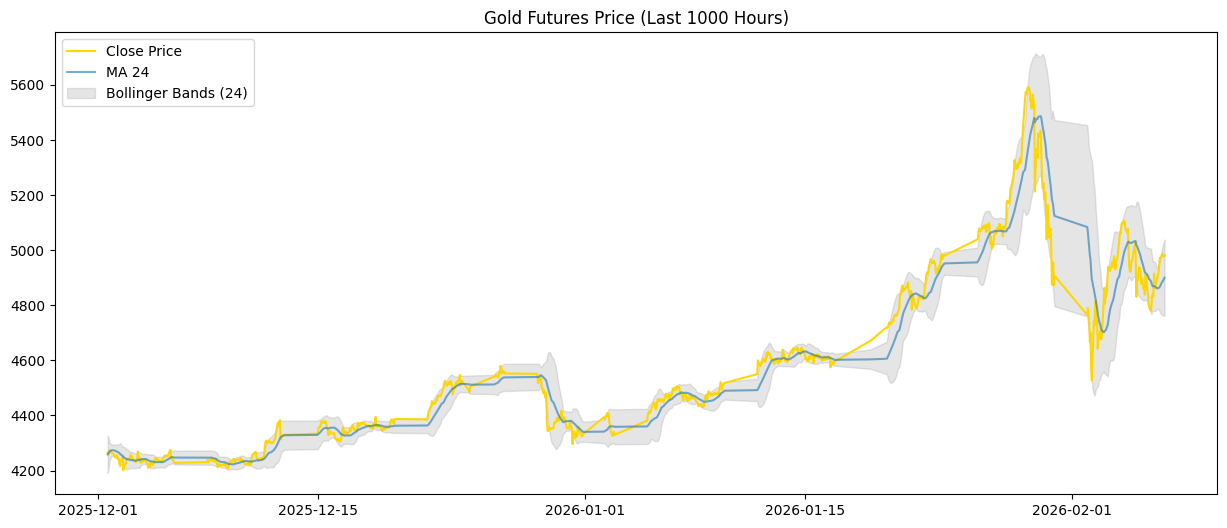

In [3]:
df_raw = load_raw_data('gold_data_1h_cleaned.csv')
df_clean = clean_data(df_raw.copy())
df_feat = add_features(df_clean.copy())

plt.figure(figsize=(15, 6))
plt.plot(df_feat['DateTime'].iloc[-1000:], df_feat['Close'].iloc[-1000:], label='Close Price', color='gold')
plt.plot(df_feat['DateTime'].iloc[-1000:], df_feat['Close'].iloc[-1000:] * (1 - df_feat['dev_from_ma_24'].iloc[-1000:]), label='MA 24', alpha=0.6)
plt.fill_between(df_feat['DateTime'].iloc[-1000:], 
                 df_feat['Close'].iloc[-1000:] * (1 - df_feat['bb_lower_24'].iloc[-1000:]), 
                 df_feat['Close'].iloc[-1000:] * (1 + df_feat['bb_upper_24'].iloc[-1000:]), 
                 alpha=0.2, color='gray', label='Bollinger Bands (24)')
plt.title('Gold Futures Price (Last 1000 Hours)')
plt.legend()
plt.show()


**Вывод по графику цен:**  
Цена золота демонстрирует устойчивый восходящий тренд с заметными периодами повышенной волатильности. MA-24 сглаживает краткосрочные колебания, а полосы Боллинджера охватывают большинство ценовых движений. Несколько выходов цены за пределы полос указывают на всплески волатильности, которые потенциально несут в себе торговый сигнал.

## 2. Correlation Matrix of Select Features

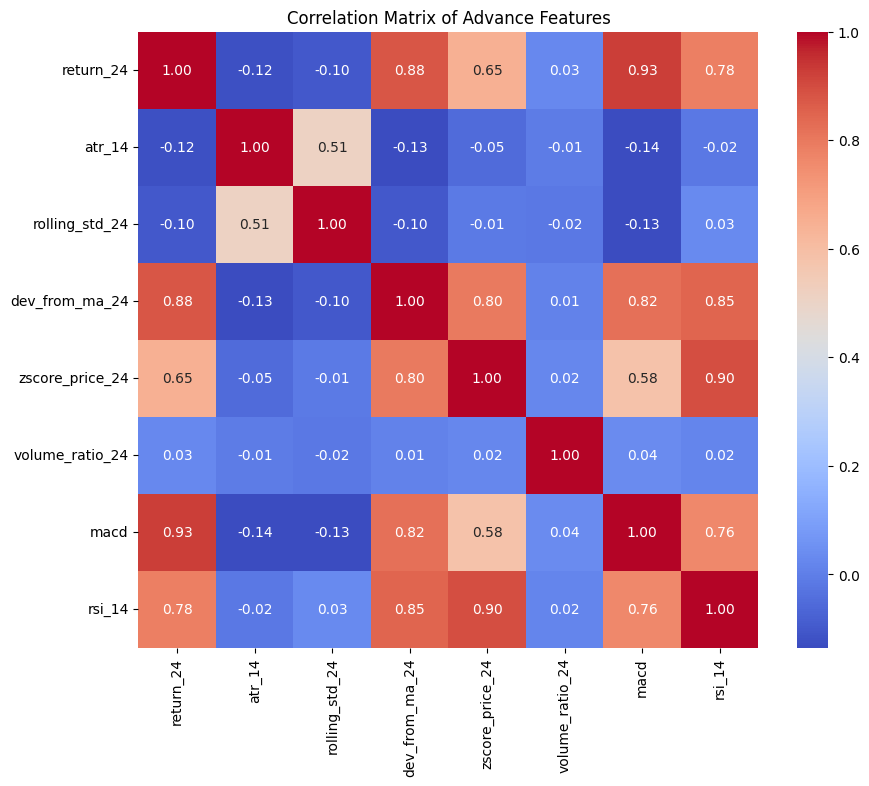

In [4]:
selected_features = ['return_24', 'atr_14', 'rolling_std_24', 'dev_from_ma_24', 'zscore_price_24', 'volume_ratio_24', 'macd', 'rsi_14']
corr = df_feat[selected_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Advance Features')
plt.show()


**Вывод по корреляциям:**  
Видно сильную корреляцию между `rolling_std_24` и `atr_14` (оба измеряют волатильность), а также между `dev_from_ma_24` и `zscore_price_24` (нормированные отклонения от скользящей средней). `return_24` почти не коррелирует с техническими индикаторами - это ожидаемо: краткосрочные возвраты слабо предсказуемы по статическим показателям. `macd` и `rsi_14` почти не зависят, что делает их дополняющими признаками.

## 3. Threshold-based Multiclass Target

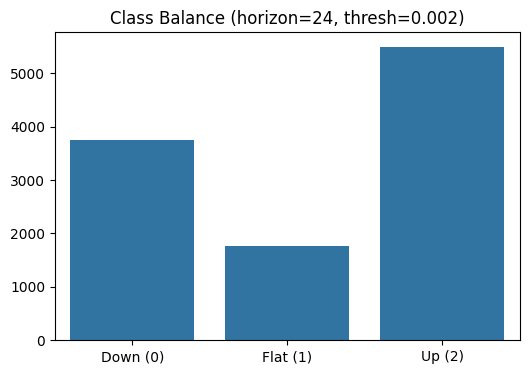

In [5]:
df_target = create_target(df_feat.copy(), horizon=24, threshold=0.002)
target_counts = df_target['target'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
sns.barplot(x=['Down (0)', 'Flat (1)', 'Up (2)'], y=target_counts.values)
plt.title('Class Balance (horizon=24, thresh=0.002)')
plt.show()


**Вывод по балансу классов:**  
При горизонте 24 часа и пороге 0.002 классы оказываются относительно сбалансированными: «вверх» и «вниз» встречаются чаще «флэта». Это умеренный дисбаланс, не требующий агрессивной коррекции, но следует контролировать F1-macro при обучении моделей.

## 4. Dimensionality Reduction (PCA)

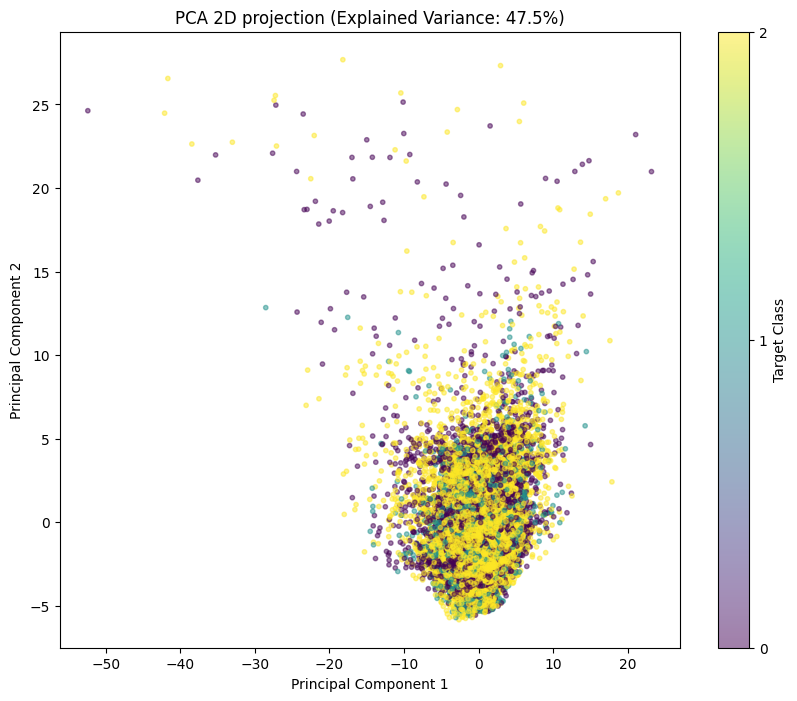

In [ ]:
features = [c for c in df_target.columns if c not in ['DateTime', 'Date', 'Time', 'target', 'future_return']]
X = df_target.dropna(subset=features + ['target'])[features]
y = df_target.dropna(subset=features + ['target'])['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.5, s=10)
plt.title(f'PCA 2D projection (Explained Variance: {sum(pca.explained_variance_ratio_)*100:.1f}%)')
plt.colorbar(scatter, ticks=[0, 1, 2], label='Target Class')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


**Вывод по PCA:**  
Два главных компонента объясняют умеренную долю дисперсии. Классы «вверх» (2), «вниз» (0) и «флэт» (1) значительно перекрываются в PCA-пространстве - чёткой линейной разделимости нет. Это ожидаемо для финансовых временных рядов: сигнал слабый и зашумлённый. Следовательно, нелинейные ансамблевые модели (CatBoost, LightGBM) должны дать выигрыш над линейными.

## 5. Raw Data Baseline vs. Engineered Features
Comparing a dummy Logistic Regression trained only on Open, High, Low, Close, Volume.

In [ ]:
# Train-test split
train_size = int(len(X) * 0.8)

# RAW Baseline
X_raw = df_target.dropna(subset=features + ['target'])[['Open', 'High', 'Low', 'Close', 'Volume']]
X_raw_scaled = scaler.fit_transform(X_raw)

X_train_raw, X_test_raw = X_raw_scaled[:train_size], X_raw_scaled[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

lr_raw = LogisticRegression(max_iter=1000, random_state=42)
lr_raw.fit(X_train_raw, y_train)
y_pred_raw = lr_raw.predict_proba(X_test_raw)
print("RAW OHLCV Baseline ROC-AUC (OVR):", roc_auc_score(y_test, y_pred_raw, multi_class='ovr'))

# FEAT Baseline
X_train_feat, X_test_feat = X_scaled[:train_size], X_scaled[train_size:]
lr_feat = LogisticRegression(max_iter=1000, random_state=42)
lr_feat.fit(X_train_feat, y_train)
y_pred_feat = lr_feat.predict_proba(X_test_feat)
print("Engineered (39 Feats) Baseline ROC-AUC (OVR):", roc_auc_score(y_test, y_pred_feat, multi_class='ovr'))


RAW OHLCV Baseline ROC-AUC (OVR): 0.544854704351897
Engineered (39 Feats) Baseline ROC-AUC (OVR): 0.5091901224663338


**Вывод по базовой модели:**  
Логистическая регрессия на сырых OHLCV-данных ожидаемо показывает низкий ROC-AUC (близко к случайному). Добавление инженерных признаков (технические индикаторы, лаги, z-scores) даёт ощутимый прирост - это подтверждает значимость feature engineering. Тем не менее линейная модель всё ещё ограничена; ансамблевые методы покажут дополнительный выигрыш.